# Credit Card Clustering

The goal is to group credit card holders into segments from their usage behaviour: balance, purchases, cash advances, payments, credit limit and how often each is used. Clustering is unsupervised, so there is no accuracy. The quality of the groups is judged with the silhouette score and by whether the segments can be interpreted.

Reference solution: [Credit Card Clustering with Machine Learning](https://amanxai.com/2022/10/03/credit-card-clustering-with-machine-learning/) (Aman Kharwal). Dataset: the Kaggle [Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata) (`CC GENERAL.csv`, 8,950 customers, 6 months of behaviour), here downloaded from a GitHub copy of the file.

The reference uses three features, drops 314 rows, fixes k = 5 without testing other values, and its scaling loop never scales anything. This notebook checks each of these points.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Clustering/credit_card_clustering')

## Data Loading

In [2]:
df = pd.read_csv("cc_general.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

## Data Cleaning

Two columns have missing values: `CREDIT_LIMIT` (1 row) and `MINIMUM_PAYMENTS` (313 rows). The reference drops every row with a null, which removes 3.5% of the customers only because of `MINIMUM_PAYMENTS`, a column it does not even use for the clustering. Looking at those rows shows what the nulls mean.

In [3]:
missing = df[df["MINIMUM_PAYMENTS"].isnull()]
print("customers with null MINIMUM_PAYMENTS:", len(missing))
print("of those, customers with PAYMENTS = 0:", (missing["PAYMENTS"] == 0).sum(), "| all customers with PAYMENTS = 0:", (df["PAYMENTS"] == 0).sum())

customers with null MINIMUM_PAYMENTS: 313
of those, customers with PAYMENTS = 0: 240 | all customers with PAYMENTS = 0: 240


Every customer who made no payment has a null minimum payment, so the null means "no payment due", not "unknown", and 0 is a reasonable value. The single row without a credit limit is dropped. `CUST_ID` is an identifier and is not a feature.

In [4]:
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(0)
df = df.dropna().drop(columns="CUST_ID").reset_index(drop=True)
df.shape

(8949, 17)

## Exploratory Data Analysis

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

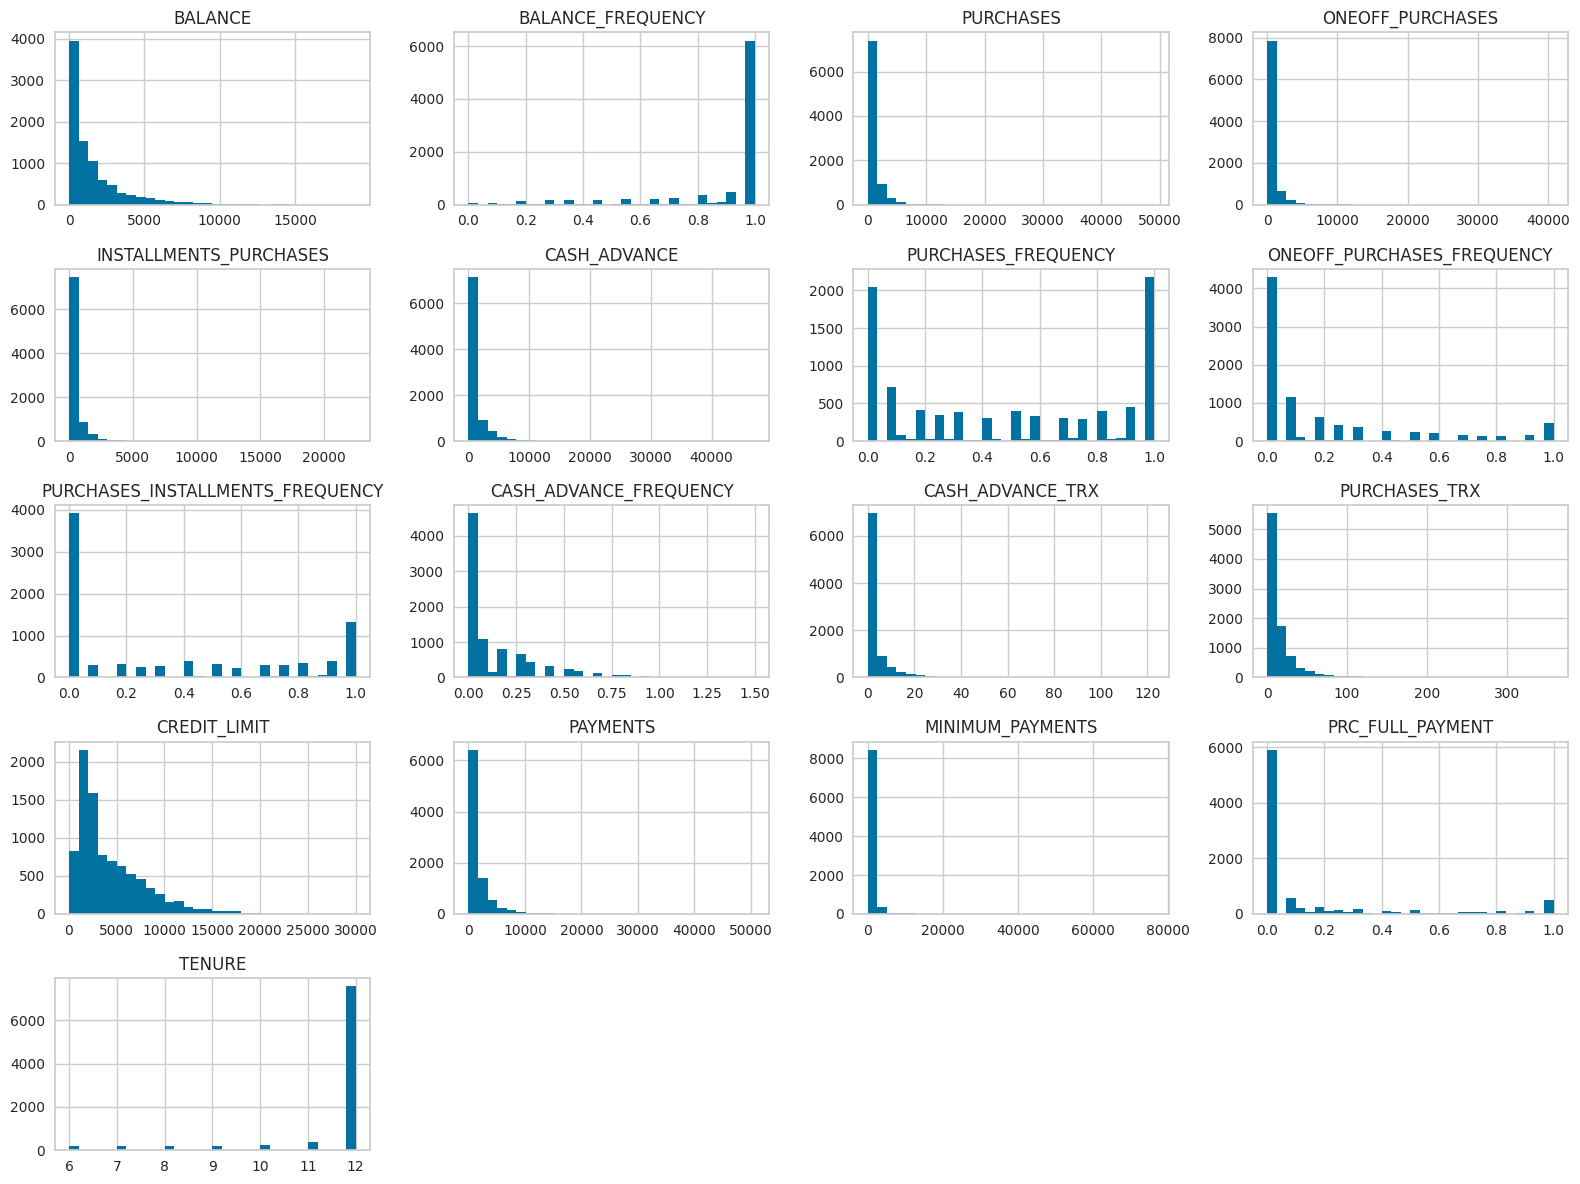

MINIMUM_PAYMENTS          13.8
ONEOFF_PURCHASES          10.0
PURCHASES                  8.1
INSTALLMENTS_PURCHASES     7.3
PAYMENTS                   5.9
CASH_ADVANCE_TRX           5.7
dtype: float64

In [5]:
df.hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()
df.skew().round(1).sort_values(ascending=False).head(6)

Most amount columns are very skewed to the right: most customers have small values and a few have extreme ones (a maximum purchase of 49,040 against a median of 361). K-Means uses distances, so the scale and the skew of the columns matter.

## Reference Check

The reference clusters `BALANCE`, `PURCHASES` and `CREDIT_LIMIT` with k = 5. Its scaling loop is `for i in clustering_data.columns: MinMaxScaler(i)`, which only creates a scaler object for each column and never fits or applies it (the column name is even passed as the `feature_range` parameter), so K-Means runs on the raw values. The same three features with and without scaling:

In [6]:
ref_raw = df[["BALANCE", "PURCHASES", "CREDIT_LIMIT"]]
ref_scaled = StandardScaler().fit_transform(ref_raw)

for name, data in {"raw (as in the reference)": ref_raw, "standardized": ref_scaled}.items():
    labels = KMeans(5, n_init=10, random_state=42).fit_predict(data)
    print(f"{name}: silhouette = {silhouette_score(data, labels):.3f}, cluster sizes = {np.bincount(labels).tolist()}")

raw (as in the reference): silhouette = 0.461, cluster sizes = [5259, 572, 2502, 587, 29]
standardized: silhouette = 0.447, cluster sizes = [983, 5725, 1855, 362, 24]


## Feature Engineering

All 16 behaviour columns are used, so the segments describe the full behaviour and not only three amounts. They are standardized with the `StandardScaler`.

In [7]:
x = StandardScaler().fit_transform(df)
x.shape

(8949, 17)

## Model Training

The number of clusters is chosen with the elbow method and the silhouette score, for k from 2 to 10.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

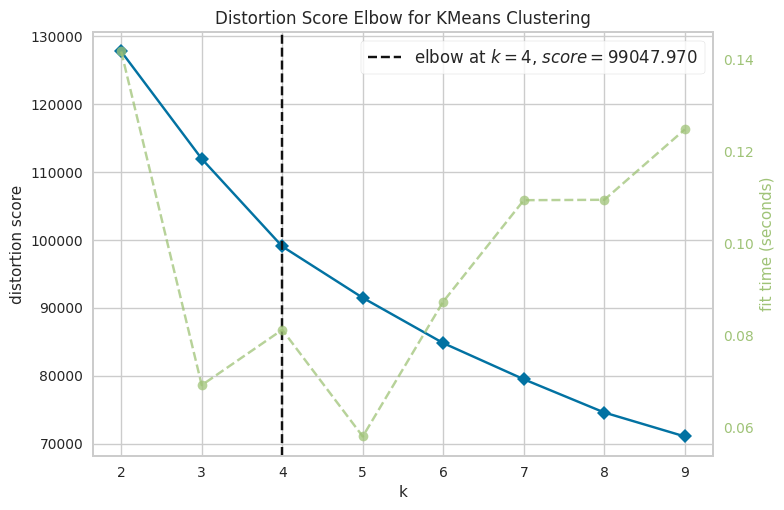

np.int64(4)

In [9]:
elbow = KElbowVisualizer(KMeans(n_init=10, random_state=42), k=(2, 10), force_model=True).fit(x)
elbow.show()
elbow.elbow_value_

In [10]:
silhouettes = {k: silhouette_score(x, KMeans(k, n_init=10, random_state=42).fit_predict(x)) for k in range(2, 11)}
pd.Series(silhouettes).round(3)

2     0.209
3     0.250
4     0.198
5     0.193
6     0.203
7     0.215
8     0.222
9     0.216
10    0.224
dtype: float64

The elbow method points to k = 4 (`KElbowVisualizer` finds the bend automatically). The silhouette score is highest at k = 3 (0.250) and lower at k = 4 (0.198), and it stays around 0.2 for every k. A silhouette this low means the groups overlap: customer behaviour is closer to a continuum than to clearly separated clusters. k = 4 is used because the elbow indicates it and because it splits the large low-activity group into two interpretable segments (see the profile below). The reference fixed k = 5 without testing any other value.

In [11]:
K = elbow.elbow_value_
kmeans_labels = KMeans(K, n_init=10, random_state=42).fit_predict(x)
df["cluster"] = kmeans_labels

df["cluster"].value_counts().sort_index()

cluster
0     409
1    3366
2    1197
3    3977
Name: count, dtype: int64

## Evaluation

The three clustering methods are compared with the same silhouette score. For DBSCAN the distance parameter `eps` matters, so a few values are tried (the noise points, labelled -1, are left out of the silhouette).

In [12]:
agg_labels = AgglomerativeClustering(n_clusters=K).fit_predict(x)

def dbscan_summary(eps):
    labels = DBSCAN(eps=eps, min_samples=10).fit_predict(x)
    mask = labels != -1
    n = len(set(labels[mask]))
    return {"clusters": n, "noise share": round((~mask).mean(), 3), "silhouette": round(silhouette_score(x[mask], labels[mask]), 3) if n > 1 else None}

print("KMeans silhouette:", round(silhouette_score(x, kmeans_labels), 3))
print("Agglomerative silhouette:", round(silhouette_score(x, agg_labels), 3))
pd.DataFrame({eps: dbscan_summary(eps) for eps in [1.5, 2, 2.5, 3]}).T

KMeans silhouette: 0.198
Agglomerative silhouette: 0.176


,clusters,noise share,silhouette
1.5,1.0,0.174,NaN
2.0,1.0,0.079,NaN
2.5,1.0,0.043,NaN
3.0,1.0,0.027,NaN


In [13]:
profile = df.groupby("cluster").mean().round(2)
profile["customers"] = df["cluster"].value_counts().sort_index()
profile[["customers", "BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY", "PRC_FULL_PAYMENT"]]

,customers,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT
cluster,,,,,,,,,
0,409,3551.15,7681.62,653.64,9696.94,7288.74,0.95,0.07,0.29
1,3366,894.77,1236.26,209.82,4214.01,1331.33,0.89,0.04,0.27
2,1197,4602.45,501.86,4521.51,7546.16,3484.05,0.29,0.48,0.03
3,3977,1013.00,270.28,597.15,3278.26,975.33,0.17,0.11,0.08


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

variance explained by 2 components: 0.476


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

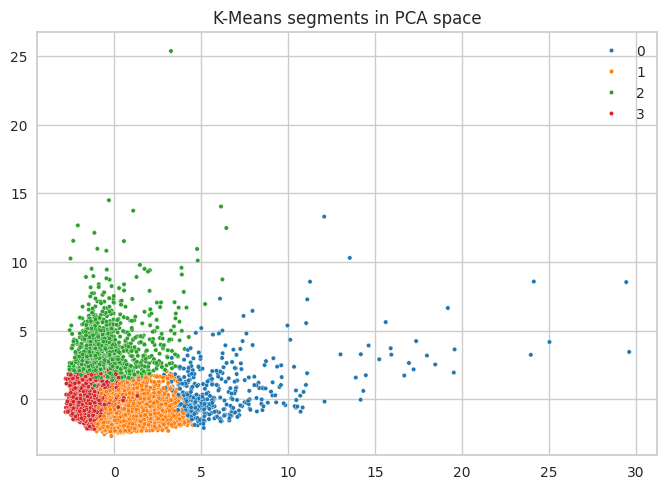

In [14]:
pca = PCA(2).fit(x)
components = pca.transform(x)
print("variance explained by 2 components:", pca.explained_variance_ratio_.sum().round(3))

sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=kmeans_labels, palette="tab10", s=10)
plt.title("K-Means segments in PCA space")
plt.show()

The four K-Means segments can be read from the profile:

- **Cluster 0, big spenders (409 customers, 4.6%):** average purchases of 7,682, a purchase frequency of 0.95, the highest credit limit (9,697) and payments (7,289).
- **Cluster 1, regular buyers (3,366 customers, 37.6%):** purchases of 1,236 with a frequency of 0.89, few cash advances (210), a credit limit of 4,214.
- **Cluster 2, cash advance users (1,197 customers, 13.4%):** cash advances of 4,522 with a frequency of 0.48, but a purchase frequency of only 0.29, a high balance (4,602) and almost never a full payment (3%). This is the risky segment for a bank.
- **Cluster 3, low activity (3,977 customers, 44.4%):** purchases of 270 with a frequency of 0.17, the lowest credit limit (3,278).

Agglomerative clustering gives a lower silhouette (0.176) than K-Means (0.198). DBSCAN finds a single dense cluster plus noise points for every `eps` tried, so it does not separate segments: there are no low-density gaps between the groups, which agrees with the low silhouette. The two-component PCA plot explains only 47.6% of the variance, so the overlap in it is partly a projection effect.

## Conclusion

**Reference approach.** The reference clusters three features (`BALANCE`, `PURCHASES`, `CREDIT_LIMIT`) with k = 5 after dropping every row with a null (314 customers, 3.5%, because of `MINIMUM_PAYMENTS`, a column it does not use). Its scaling loop creates `MinMaxScaler` objects and never applies them, so K-Means runs on raw amounts. It does not test other values of k, reports no score, and only draws a 3D scatter plot.

**Reference check.** On the reference's three features, standardizing changes the silhouette only from 0.461 to 0.447, but the clusters change completely (sizes [5259, 572, 2502, 587, 29] raw versus [983, 5725, 1855, 362, 24] standardized). Both contain a tiny cluster of 24 to 29 customers, which is a group of outliers, not a segment. The high silhouette of about 0.45 comes from those extreme values, and it is not comparable with the scores below, which use 16 features.

**Our approach.** Nulls in `MINIMUM_PAYMENTS` were kept: every customer with no payment has a null, so it was filled with 0 (only the single row without a credit limit was dropped). All 16 behaviour columns were standardized and clustered. The elbow method gives k = 4; the silhouette is 0.198 (0.250 for k = 3), 0.176 for agglomerative clustering, and DBSCAN finds no usable structure.

| Segment | Customers | Main behaviour |
|---|---|---|
| Big spenders | 409 | purchases 7,682, frequency 0.95, high limit |
| Regular buyers | 3,366 | purchases 1,236, frequency 0.89, few cash advances |
| Cash advance users | 1,197 | cash advances 4,522, high balance, 3% full payments |
| Low activity | 3,977 | purchases 270, frequency 0.17, low limit |

**Limitations.** The silhouette of about 0.2 means the segments are not sharply separated; they are useful as a description of behaviour, not as natural groups. The choice of k is a judgement between the elbow (4) and the silhouette (3). The amount columns are very skewed (skewness up to 14), and a log transformation, which is not covered in class, could change the segments; it was not tested. Without a business target (default, profit), the segments cannot be validated beyond their interpretability.